In [4]:
pip install yfinance

     ---------------------------------------- 0.0/3.0 MB ? eta -:--:--
     --- ------------------------------------ 0.3/3.0 MB ? eta -:--:--
     ------ --------------------------------- 0.5/3.0 MB 1.9 MB/s eta 0:00:02
     ---------- ----------------------------- 0.8/3.0 MB 1.5 MB/s eta 0:00:02
     ------------- -------------------------- 1.0/3.0 MB 1.3 MB/s eta 0:00:02
     ----------------- ---------------------- 1.3/3.0 MB 1.4 MB/s eta 0:00:02
     ------------------------ --------------- 1.8/3.0 MB 1.5 MB/s eta 0:00:01
     --------------------------- ------------ 2.1/3.0 MB 1.5 MB/s eta 0:00:01
     ---------------------------------- ----- 2.6/3.0 MB 1.6 MB/s eta 0:00:01
     -------------------------------------- - 2.9/3.0 MB 1.6 MB/s eta 0:00:01
     ---------------------------------------- 3.0/3.0 MB 1.6 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getti

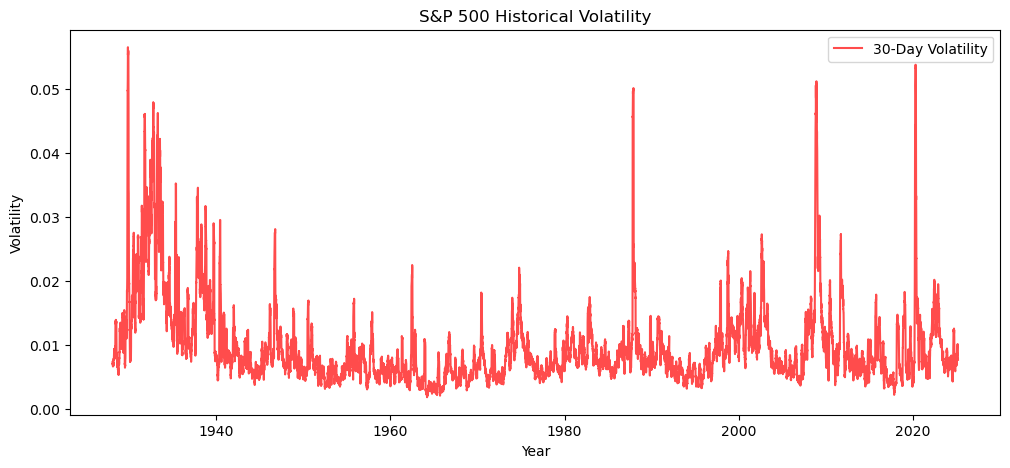

In [6]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Download historical S&P 500 data
sp500 = yf.Ticker("^GSPC")
data = sp500.history(period="max")  # Get max available historical data

# Calculate daily returns and rolling volatility
data["Returns"] = data["Close"].pct_change()
data["Volatility"] = data["Returns"].rolling(window=30).std()  # 30-day rolling volatility

# Drop NaN values from the rolling window
data.dropna(inplace=True)

# Plot to check volatility trends
plt.figure(figsize=(12, 5))
plt.plot(data.index, data["Volatility"], label="30-Day Volatility", color="red", alpha=0.7)
plt.xlabel("Year")
plt.ylabel("Volatility")
plt.title("S&P 500 Historical Volatility")
plt.legend()
plt.show()

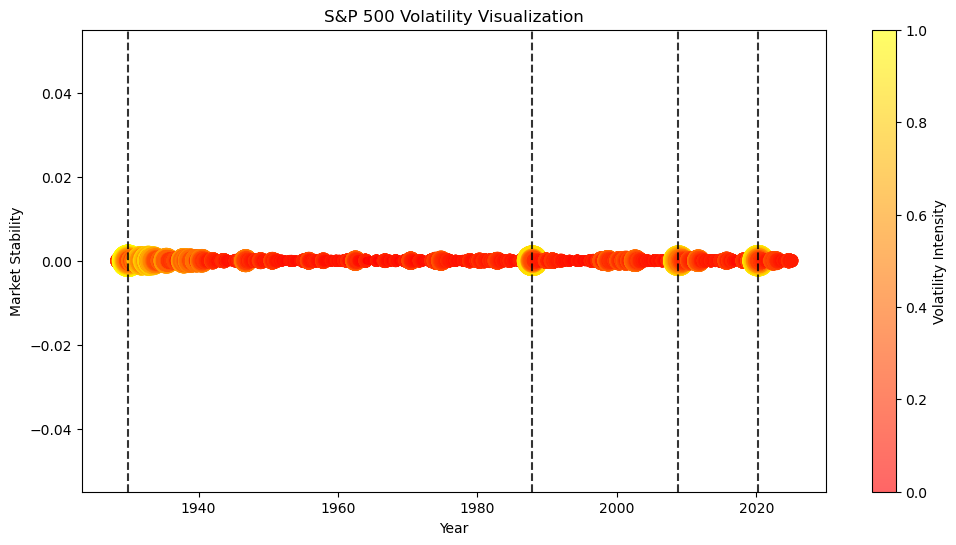

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Extract relevant data
dates = data.index
volatility = data["Volatility"].values

# Normalize volatility for color mapping
norm_volatility = (volatility - np.min(volatility)) / (np.max(volatility) - np.min(volatility))

# Define figure
fig, ax = plt.subplots(figsize=(12, 6))

# Create scatter plot where size & color represent volatility
scatter = ax.scatter(dates, np.zeros_like(dates), s=norm_volatility * 500,  # Shape size
                     c=norm_volatility, cmap="autumn", alpha=0.6)

# Highlight major crashes
crash_dates = ["1929-10-29", "1987-10-19", "2008-09-29", "2020-03-16"]
for crash in crash_dates:
    if crash in data.index:
        ax.axvline(pd.Timestamp(crash), color="black", linestyle="dashed", alpha=0.8)

# Labels
ax.set_title("S&P 500 Volatility Visualization")
ax.set_xlabel("Year")
ax.set_ylabel("Market Stability")
plt.colorbar(scatter, label="Volatility Intensity")

plt.show()